# WasteWise AI – Exploratory Data Analysis (EDA)

## Smart Cafeteria Food Waste Prediction System

**Machine Learning Task:** Regression  
**Target Variable:** `food_waste_kg`

### Objective
This notebook performs exploratory data analysis and data quality assessment on the WasteWise AI training dataset.

The analysis focuses on:
- Dataset structure and data types
- Descriptive statistics
- Missing values and duplicate records
- Categorical inconsistencies
- Target variable distribution
- Numerical and categorical feature distributions
- Correlation analysis
- Outlier detection
- Date coverage
- Potential data leakage
- Feature removal decisions
- Preprocessing recommendations

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("../../dataset/train.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (911, 12)


,ID,date,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,food_waste_kg
0,0,2022-12-19,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy,28.946465
1,1,2023-11-21,244,15,10.317872,64.430475,1,0,42.311779,NaN,MeAt,51.549053
2,4,2022-02-01,148,16,27.714300,69.046113,1,0,41.184305,Beginner,MeAt,53.008323
3,5,2023-03-19,157,19,19.173902,46.292823,6,0,41.543492,Beginner,MeAt,48.621527
4,6,2022-07-18,297,10,26.375233,79.741064,0,0,26.525097,Intermediate,MEAT,44.156984


## 1. Dataset Structure and Data Types

This section examines the dimensions, column names, data types, and general structure of the training dataset.

In [15]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
for column in df.columns:
    print("-", column)

print("\nData Types:")
print(df.dtypes)

Number of rows: 911
Number of columns: 12

Column Names:
- ID
- date
- meals_served
- kitchen_staff
- temperature_C
- humidity_percent
- day_of_week
- special_event
- past_waste_kg
- staff_experience
- waste_category
- food_waste_kg

Data Types:
ID                    int64
date                 object
meals_served          int64
kitchen_staff         int64
temperature_C       float64
humidity_percent    float64
day_of_week           int64
special_event         int64
past_waste_kg       float64
staff_experience     object
waste_category       object
food_waste_kg       float64
dtype: object


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                911 non-null    int64  
 1   date              911 non-null    object 
 2   meals_served      911 non-null    int64  
 3   kitchen_staff     911 non-null    int64  
 4   temperature_C     911 non-null    float64
 5   humidity_percent  911 non-null    float64
 6   day_of_week       911 non-null    int64  
 7   special_event     911 non-null    int64  
 8   past_waste_kg     911 non-null    float64
 9   staff_experience  747 non-null    object 
 10  waste_category    911 non-null    object 
 11  food_waste_kg     911 non-null    float64
dtypes: float64(4), int64(5), object(3)
memory usage: 85.5+ KB


## 2. Descriptive Statistics

Descriptive statistics are used to understand the central tendency, spread, and range of the numerical features in the dataset.

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,911.0,528.327113,305.072794,0.000000,266.000000,531.000000,795.500000,1049.000000
meals_served,911.0,375.405049,502.812717,100.000000,211.000000,306.000000,407.000000,4730.000000
kitchen_staff,911.0,11.900110,4.285153,5.000000,8.000000,12.000000,15.000000,19.000000
temperature_C,911.0,22.189280,8.922389,-10.372207,15.684585,22.115040,28.804294,60.000000
humidity_percent,911.0,60.761313,17.330821,30.121111,46.017835,61.633960,75.787910,89.982828
day_of_week,911.0,3.014270,2.009542,0.000000,1.000000,3.000000,5.000000,6.000000
special_event,911.0,0.085620,0.279956,0.000000,0.000000,0.000000,0.000000,1.000000
past_waste_kg,911.0,27.015691,12.774223,5.008394,16.091383,26.854109,38.149878,49.803703
food_waste_kg,911.0,44.842691,27.934366,10.819048,32.887912,41.146930,50.046681,274.328783


## 3. Data Quality Assessment

This section investigates missing values, duplicate records, and inconsistencies in categorical variables. Identifying these issues is important before preprocessing and model development.

In [18]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage.round(2)
})

missing_summary

,Missing Values,Percentage (%)
ID,0,0.0
date,0,0.0
meals_served,0,0.0
kitchen_staff,0,0.0
temperature_C,0,0.0
humidity_percent,0,0.0
day_of_week,0,0.0
special_event,0,0.0
past_waste_kg,0,0.0
staff_experience,164,18.0


### Duplicate Records

In [19]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Categorical Value Inspection

Categorical variables are inspected to identify inconsistent labels, capitalization differences, and other data-quality issues.

In [20]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


date:
date
2022-01-28    2
2022-01-13    2
2022-02-01    2
2022-01-11    2
2022-01-05    2
             ..
2024-05-21    1
2022-03-29    1
2022-11-27    1
2023-04-12    1
2024-05-10    1
Name: count, Length: 867, dtype: int64

staff_experience:
staff_experience
Beginner        191
EXPERT          186
Intermediate    186
intermediate    184
NaN             164
Name: count, dtype: int64

waste_category:
waste_category
MEAT          210
dairy         180
Vegetables    176
GRAINS        176
MeAt          169
Name: count, dtype: int64


In [21]:
for column in ["staff_experience", "waste_category"]:
    print(f"\nUnique values in {column}:")
    print(df[column].unique())


Unique values in staff_experience:
['intermediate' nan 'Beginner' 'Intermediate' 'EXPERT']

Unique values in waste_category:
['dairy' 'MeAt' 'MEAT' 'Vegetables' 'GRAINS']


### Data Quality Findings

The data quality assessment identified the following issues:

- `staff_experience` contains 164 missing values, representing approximately 18% of the dataset.
- No duplicate records were found in the dataset.
- `staff_experience` contains inconsistent capitalization. For example, `Intermediate` and `intermediate` represent the same category.
- `waste_category` also contains inconsistent capitalization, such as `MEAT` and `MeAt`.
- The `date` column is currently stored as an object rather than a datetime data type.

These issues should be addressed during the preprocessing stage. Missing values in `staff_experience` require an appropriate imputation strategy, categorical labels should be standardized, and the `date` feature should be converted and used to derive meaningful temporal features.

## 4. Target Variable Analysis

The target variable for WasteWise AI is `food_waste_kg`. Its distribution is analysed to understand the typical amount of food waste, variability, skewness, and potential extreme values.

In [22]:
target_stats = df["food_waste_kg"].describe()

print(target_stats)
print("\nSkewness:", round(df["food_waste_kg"].skew(), 3))

count    911.000000
mean      44.842691
std       27.934366
min       10.819048
25%       32.887912
50%       41.146930
75%       50.046681
max      274.328783
Name: food_waste_kg, dtype: float64

Skewness: 4.991


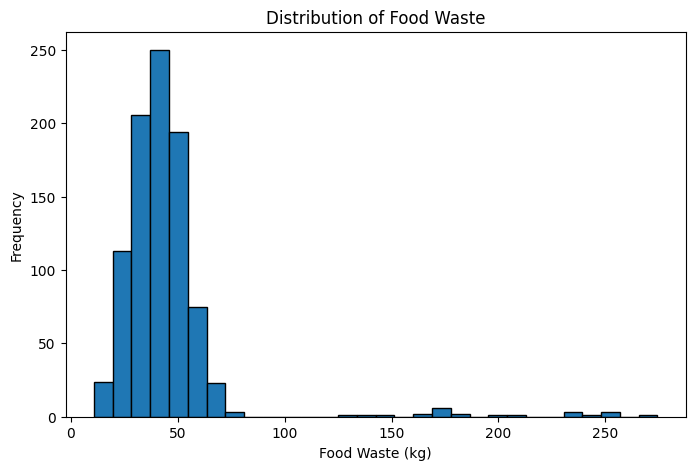

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(df["food_waste_kg"], bins=30, edgecolor="black")

plt.title("Distribution of Food Waste")
plt.xlabel("Food Waste (kg)")
plt.ylabel("Frequency")

plt.show()

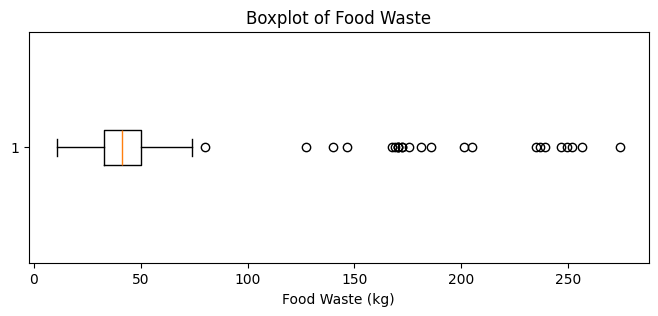

In [24]:
plt.figure(figsize=(8, 3))

plt.boxplot(df["food_waste_kg"], vert=False)

plt.title("Boxplot of Food Waste")
plt.xlabel("Food Waste (kg)")

plt.show()

### Target Variable Findings

The `food_waste_kg` target variable has a mean of approximately 44.84 kg and a median of approximately 41.15 kg. The maximum value reaches approximately 274.33 kg.

The calculated skewness of 4.991 indicates that the target distribution is strongly positively skewed. The histogram confirms that most observations are concentrated at lower waste levels, while a relatively small number of observations contain much higher food waste values.

The boxplot also identifies several high-value observations as potential outliers. However, these observations should not be removed automatically because they may represent genuine high-volume cafeteria operations. Their relationship with operational features such as `meals_served` should be investigated before selecting an outlier treatment strategy.

## 5. Numerical Feature Analysis

The numerical predictor variables are analysed to understand their distributions, ranges, skewness, and potential extreme values.

In [25]:
numerical_features = [
    "meals_served",
    "kitchen_staff",
    "temperature_C",
    "humidity_percent",
    "past_waste_kg"
]

df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
meals_served,911.0,375.405049,502.812717,100.000000,211.000000,306.000000,407.000000,4730.000000
kitchen_staff,911.0,11.900110,4.285153,5.000000,8.000000,12.000000,15.000000,19.000000
temperature_C,911.0,22.189280,8.922389,-10.372207,15.684585,22.115040,28.804294,60.000000
humidity_percent,911.0,60.761313,17.330821,30.121111,46.017835,61.633960,75.787910,89.982828
past_waste_kg,911.0,27.015691,12.774223,5.008394,16.091383,26.854109,38.149878,49.803703


In [26]:
print("Skewness of Numerical Features:\n")

for column in numerical_features:
    print(f"{column}: {df[column].skew():.3f}")

Skewness of Numerical Features:

meals_served: 6.581
kitchen_staff: 0.020
temperature_C: 0.112
humidity_percent: -0.093
past_waste_kg: 0.016


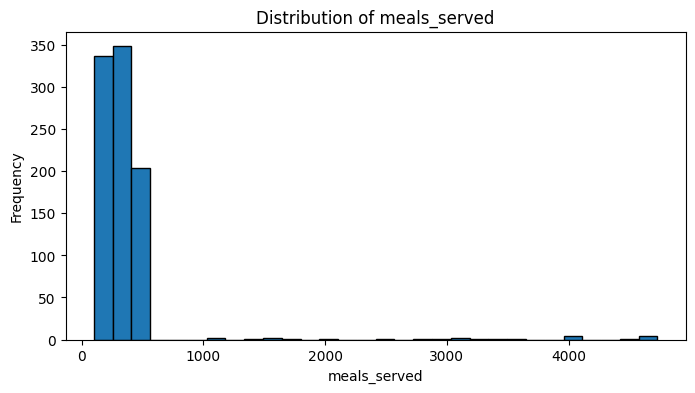

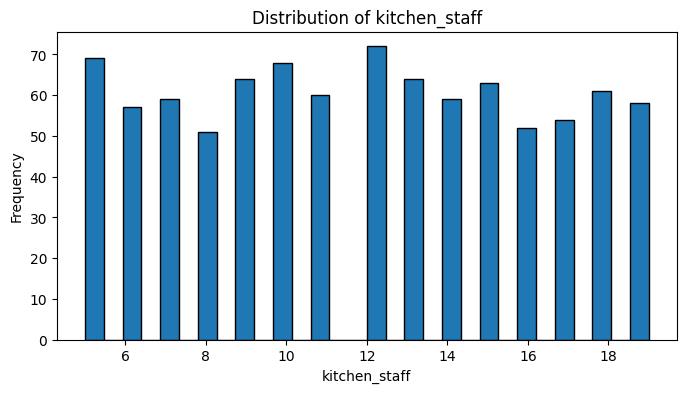

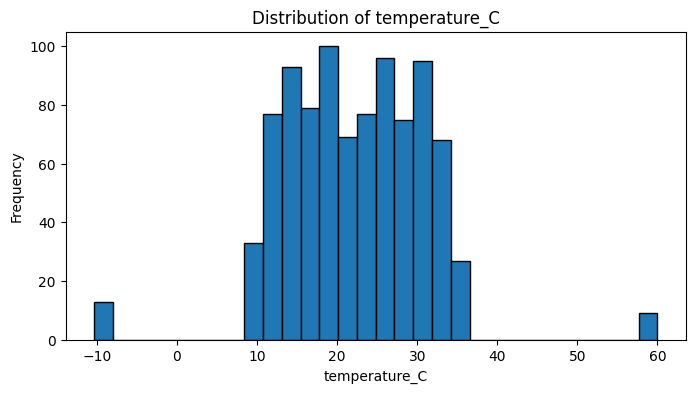

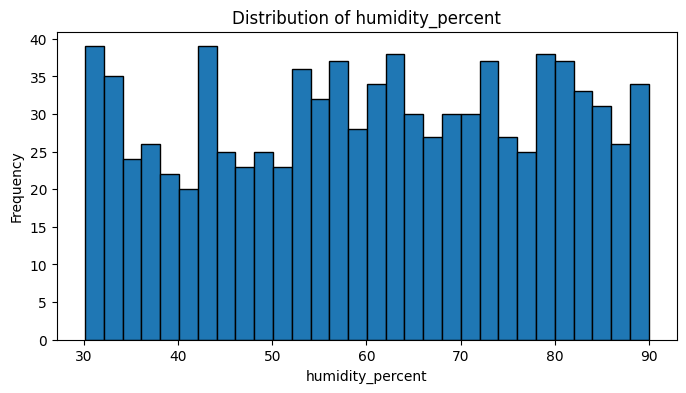

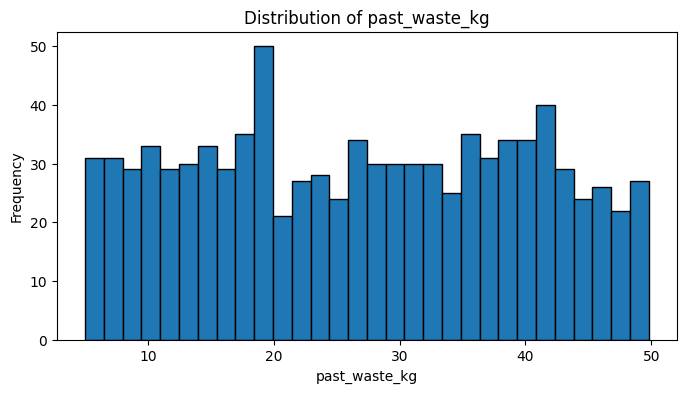

In [27]:
for column in numerical_features:
    plt.figure(figsize=(8, 4))
    plt.hist(df[column], bins=30, edgecolor="black")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

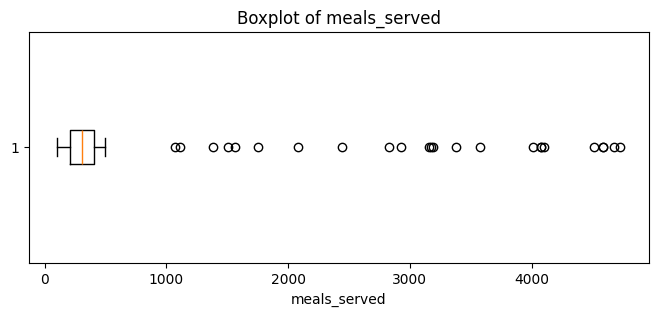

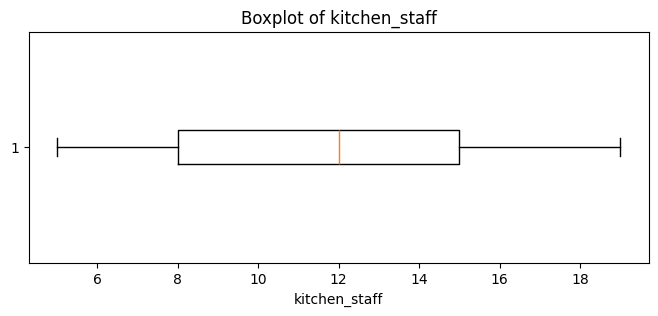

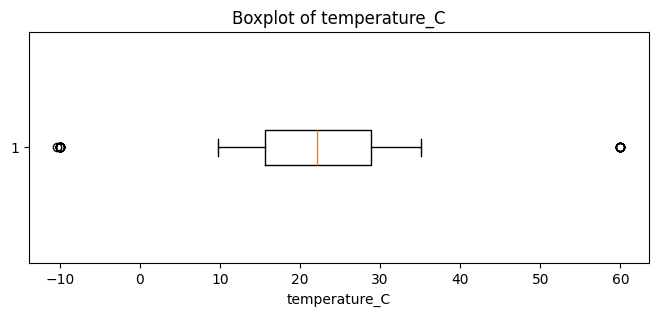

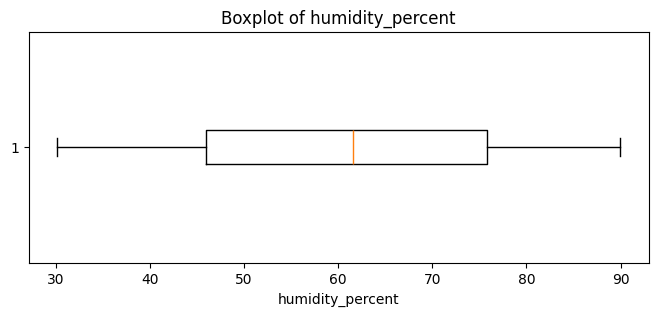

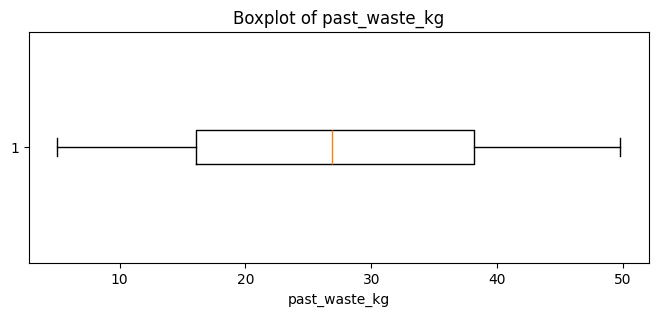

In [28]:
for column in numerical_features:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df[column], vert=False)
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

## 6. Outlier Detection

Potential outliers in the numerical variables are identified using the Interquartile Range (IQR) method. Values below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR are considered potential outliers.

These observations are identified for further investigation rather than being removed immediately, since some extreme values may represent genuine cafeteria operating conditions.

In [29]:
outlier_summary = []

for column in numerical_features + ["food_waste_kg"]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": len(outliers),
        "Outlier Percentage": round(len(outliers) / len(df) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,meals_served,-83.00,701.00,24,2.63
1,kitchen_staff,-2.50,25.50,0,0.00
2,temperature_C,-3.99,48.48,22,2.41
3,humidity_percent,1.36,120.44,0,0.00
4,past_waste_kg,-17.00,71.24,0,0.00
5,food_waste_kg,7.15,75.78,24,2.63


In [30]:
Q1 = df["meals_served"].quantile(0.25)
Q3 = df["meals_served"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

meal_outliers = df[df["meals_served"] > upper_bound]

meal_outliers[
    ["date", "meals_served", "kitchen_staff", "past_waste_kg", "food_waste_kg"]
].sort_values("meals_served", ascending=False)

,date,meals_served,kitchen_staff,past_waste_kg,food_waste_kg
687,2024-01-06,4730,13,14.096723,236.740804
368,2023-12-24,4680,14,26.208872,251.538932
813,2022-01-15,4590,8,8.944243,170.347774
714,2022-01-15,4590,8,8.944243,170.347774
520,2022-09-26,4510,8,7.293869,170.554947
380,2024-03-31,4100,18,5.993863,168.868788
443,2022-01-19,4080,7,19.401229,172.155582
425,2022-01-19,4080,7,19.401229,172.155582
448,2023-01-11,4010,16,31.732226,256.325524
284,2022-07-16,3580,7,23.680622,181.142320


In [31]:
Q1 = df["temperature_C"].quantile(0.25)
Q3 = df["temperature_C"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

temperature_outliers = df[
    (df["temperature_C"] < lower_bound) |
    (df["temperature_C"] > upper_bound)
]

temperature_outliers[
    ["date", "temperature_C", "meals_served", "food_waste_kg"]
].sort_values("temperature_C")

,date,temperature_C,meals_served,food_waste_kg
12,2022-01-25,-10.372207,376,50.568699
102,2024-02-24,-10.000000,134,36.163483
238,2023-03-06,-10.000000,453,71.752271
345,2024-02-01,-10.000000,472,46.991245
384,2022-03-15,-10.000000,359,70.472339
463,2023-07-30,-10.000000,341,47.533061
445,2023-01-29,-10.000000,459,60.690374
407,2022-01-25,-10.000000,376,50.568699
492,2022-04-04,-10.000000,152,30.175709
768,2024-05-07,-10.000000,335,52.082864


### Outlier Analysis Findings

The IQR analysis identified potential outliers in `meals_served`, `temperature_C`, and the target variable `food_waste_kg`.

- `meals_served` contains 24 potential outliers (2.63%).
- `temperature_C` contains 22 potential outliers (2.41%).
- `food_waste_kg` contains 24 potential outliers (2.63%).
- No IQR-based outliers were detected in `kitchen_staff`, `humidity_percent`, or `past_waste_kg`.

The extreme observations will not be removed during EDA. They should be investigated during preprocessing because some may represent genuine high-volume cafeteria operations, while others may represent anomalous values.

## 7. Feature Relationships and Correlation Analysis

The relationships between numerical predictor variables and the target variable `food_waste_kg` are analysed to identify features that may have predictive importance.

In [32]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

target_correlation = (
    correlation_matrix["food_waste_kg"]
    .sort_values(ascending=False)
)

target_correlation

food_waste_kg       1.000000
meals_served        0.852128
past_waste_kg       0.260767
special_event       0.118757
day_of_week         0.008090
kitchen_staff       0.007192
temperature_C      -0.015911
ID                 -0.020233
humidity_percent   -0.021793
Name: food_waste_kg, dtype: float64

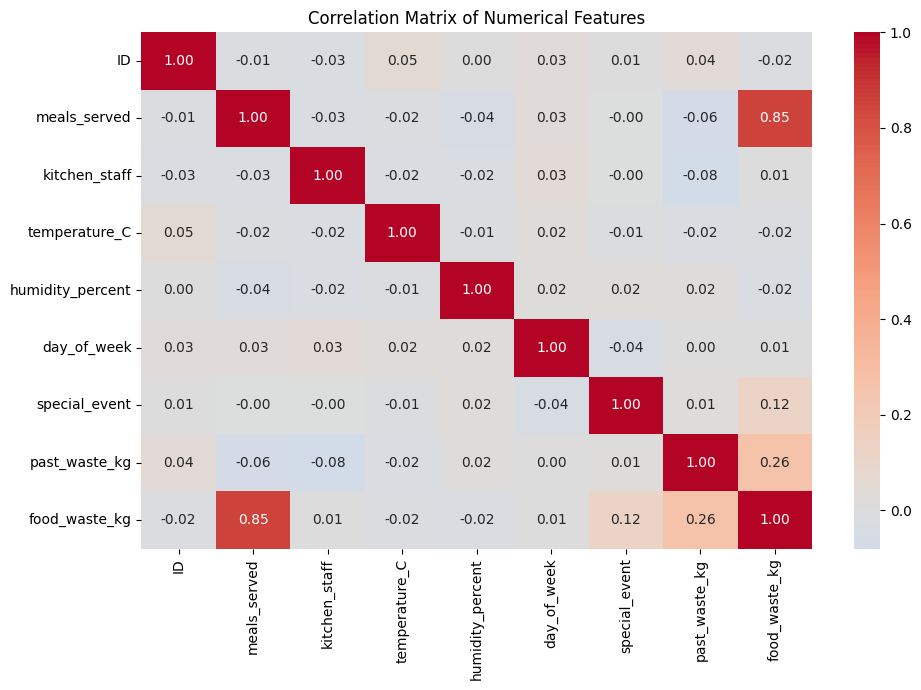

In [33]:
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Meals Served vs Food Waste

Since `meals_served` has the strongest correlation with `food_waste_kg`, their relationship is examined using a scatter plot.

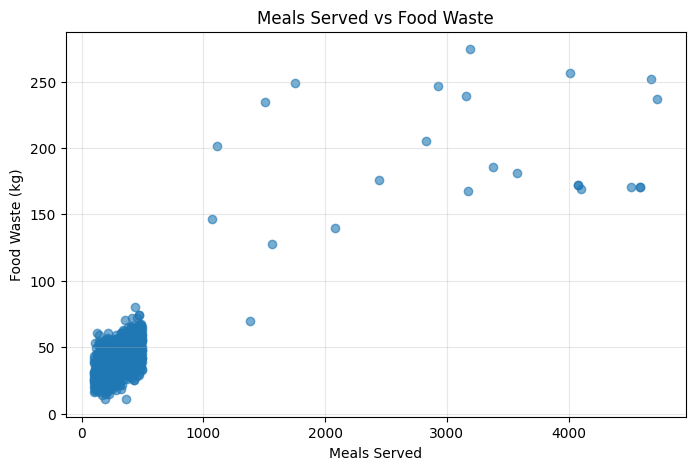

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["meals_served"],
    df["food_waste_kg"],
    alpha=0.6
)

plt.xlabel("Meals Served")
plt.ylabel("Food Waste (kg)")
plt.title("Meals Served vs Food Waste")

plt.grid(alpha=0.3)
plt.show()

### Meals Served Relationship Findings

The scatter plot shows a strong positive relationship between `meals_served` and `food_waste_kg`. Cafeteria observations with a larger number of meals served generally produce higher amounts of food waste.

However, the plot also shows a small group of extreme observations where the number of meals served is substantially higher than the majority of the dataset. These observations contribute to the strong overall correlation between meals served and food waste.

These extreme values should not be removed automatically because they may represent genuine high-volume cafeteria operations. Their treatment will be evaluated during preprocessing and model development.

In [35]:
Q1 = df["meals_served"].quantile(0.25)
Q3 = df["meals_served"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

normal_meals = df[df["meals_served"] <= upper_bound]

print("Upper IQR bound:", upper_bound)
print("Normal observations:", len(normal_meals))

print(
    "Correlation without meals_served outliers:",
    round(normal_meals["meals_served"].corr(
        normal_meals["food_waste_kg"]
    ), 3)
)

Upper IQR bound: 701.0
Normal observations: 887
Correlation without meals_served outliers: 0.527


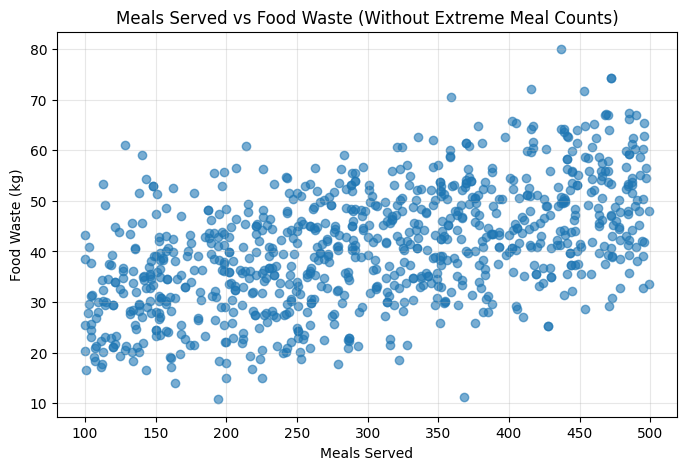

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    normal_meals["meals_served"],
    normal_meals["food_waste_kg"],
    alpha=0.6
)

plt.xlabel("Meals Served")
plt.ylabel("Food Waste (kg)")
plt.title("Meals Served vs Food Waste (Without Extreme Meal Counts)")
plt.grid(alpha=0.3)

plt.show()

### Effect of Extreme Meal Counts

The original correlation between `meals_served` and `food_waste_kg` was approximately 0.85. Since `meals_served` contained several extreme observations, the relationship was also examined after excluding values above the IQR upper bound of 701 meals.

After excluding the 24 extreme observations, 887 records remained and the correlation decreased to approximately 0.53. The scatter plot still shows a clear positive relationship between meals served and food waste.

This indicates that the strong overall correlation is partly influenced by high-volume observations, but `meals_served` remains an important predictor of food waste even within the typical operating range. Therefore, the extreme observations should be carefully evaluated during preprocessing rather than automatically removed.

### Past Waste vs Food Waste

`past_waste_kg` has the second-highest positive correlation with the target. Its relationship with current food waste is examined using a scatter plot.

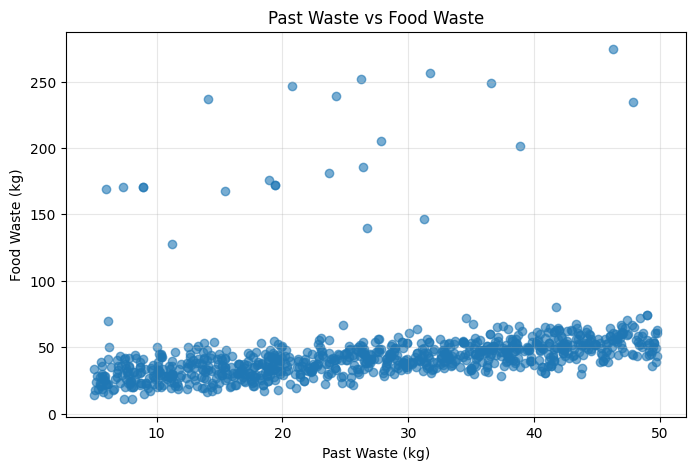

In [37]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["past_waste_kg"],
    df["food_waste_kg"],
    alpha=0.6
)

plt.xlabel("Past Waste (kg)")
plt.ylabel("Food Waste (kg)")
plt.title("Past Waste vs Food Waste")

plt.grid(alpha=0.3)
plt.show()

### Past Waste Relationship Findings

The scatter plot indicates a positive relationship between `past_waste_kg` and `food_waste_kg` for the majority of observations. However, several observations contain unusually high current food waste values.

These extreme target values may influence the overall correlation coefficient. Therefore, the relationship is examined again using observations within the normal range of `food_waste_kg`.

In [38]:
Q1 = df["food_waste_kg"].quantile(0.25)
Q3 = df["food_waste_kg"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

normal_waste = df[
    (df["food_waste_kg"] >= lower_bound) &
    (df["food_waste_kg"] <= upper_bound)
]

print("Food waste lower IQR bound:", round(lower_bound, 2))
print("Food waste upper IQR bound:", round(upper_bound, 2))
print("Normal observations:", len(normal_waste))

print(
    "Correlation without food_waste_kg outliers:",
    round(
        normal_waste["past_waste_kg"].corr(
            normal_waste["food_waste_kg"]
        ),
        3
    )
)

Food waste lower IQR bound: 7.15
Food waste upper IQR bound: 75.78
Normal observations: 887
Correlation without food_waste_kg outliers: 0.692


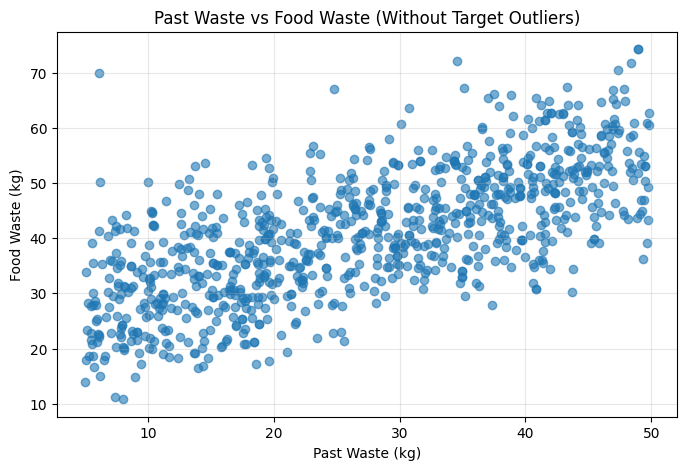

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(
    normal_waste["past_waste_kg"],
    normal_waste["food_waste_kg"],
    alpha=0.6
)

plt.xlabel("Past Waste (kg)")
plt.ylabel("Food Waste (kg)")
plt.title("Past Waste vs Food Waste (Without Target Outliers)")

plt.grid(alpha=0.3)
plt.show()

### Past Waste Analysis Conclusion

The original correlation between `past_waste_kg` and `food_waste_kg` was approximately 0.261. However, the scatter plot showed that several extreme values of the target variable were influencing this relationship.

After excluding the 24 `food_waste_kg` observations identified as outliers using the IQR method, 887 observations remained. The correlation increased to approximately 0.692.

This indicates a moderately strong positive relationship between historical food waste and current food waste under typical operating conditions. Therefore, `past_waste_kg` is considered a potentially useful predictive feature and should be retained for the modelling stage.

The outliers are not permanently removed during EDA. Their treatment will be evaluated during preprocessing and model development.

## 8. Categorical Feature Analysis

Categorical variables are analysed against the target variable to determine whether different categories are associated with differences in food waste.

The analysis focuses on `staff_experience` and `waste_category`. Category labels are temporarily standardized for analysis without modifying the original dataset.

In [40]:
eda_categories = df.copy()

eda_categories["staff_experience"] = (
    eda_categories["staff_experience"]
    .str.strip()
    .str.lower()
)

eda_categories["waste_category"] = (
    eda_categories["waste_category"]
    .str.strip()
    .str.lower()
)

staff_waste_summary = (
    eda_categories
    .groupby("staff_experience")["food_waste_kg"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

staff_waste_summary

,count,mean,median,std
staff_experience,,,,
beginner,191,47.85,42.20,30.04
expert,186,45.92,41.40,30.56
intermediate,370,44.46,40.95,28.23


<Figure size 800x500 with 0 Axes>

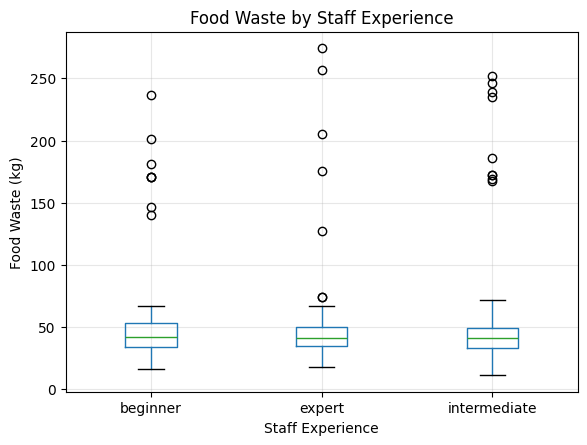

In [41]:
plt.figure(figsize=(8, 5))

eda_categories.boxplot(
    column="food_waste_kg",
    by="staff_experience"
)

plt.title("Food Waste by Staff Experience")
plt.suptitle("")
plt.xlabel("Staff Experience")
plt.ylabel("Food Waste (kg)")
plt.grid(alpha=0.3)

plt.show()

### Staff Experience Findings

After standardizing inconsistent category labels, three staff experience
levels were identified: Beginner, Intermediate, and Expert.

Beginner staff had the highest mean food waste at approximately 47.85 kg,
followed by Expert staff at 45.92 kg and Intermediate staff at 44.46 kg.

However, the median values were relatively similar across all three groups,
ranging from approximately 40.95 kg to 42.20 kg. This suggests that staff
experience alone may not have a strong relationship with food waste.

A total of 164 observations contain missing staff experience values. These
missing values will be handled during the preprocessing stage rather than
being modified during EDA.

In [42]:
category_waste_summary = (
    eda_categories
    .groupby("waste_category")["food_waste_kg"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

category_waste_summary

,count,mean,median,std
waste_category,,,,
dairy,180,43.56,41.51,22.75
grains,176,42.00,40.32,20.30
meat,379,46.30,41.26,32.97
vegetables,176,45.85,42.60,27.45


<Figure size 800x500 with 0 Axes>

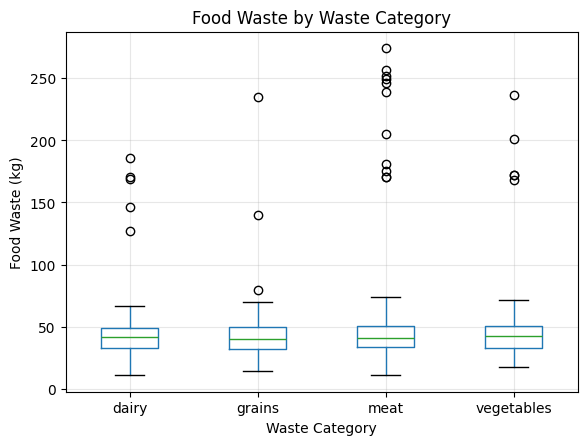

In [43]:
plt.figure(figsize=(8, 5))

eda_categories.boxplot(
    column="food_waste_kg",
    by="waste_category"
)

plt.title("Food Waste by Waste Category")
plt.suptitle("")
plt.xlabel("Waste Category")
plt.ylabel("Food Waste (kg)")
plt.grid(alpha=0.3)

plt.show()

### Waste Category Findings

After standardizing inconsistent category labels, four waste categories were
identified: Dairy, Grains, Meat, and Vegetables.

Meat had the highest mean food waste at approximately 46.30 kg, followed by
Vegetables at 45.85 kg, Dairy at 43.56 kg, and Grains at 42.00 kg.

However, the median food waste values were relatively similar across all
categories, ranging from approximately 40.32 kg to 42.60 kg. This suggests
that waste category alone does not show a strong separation in typical food
waste levels.

The Meat category showed the highest variability, with a standard deviation
of approximately 32.97 kg. This may partly reflect the extreme food-waste
observations identified earlier.

The categorical labels should be standardized and encoded during the
preprocessing stage before model training.

## 9. Date and Temporal Analysis

The `date` feature is analysed to identify possible temporal patterns in food
waste. Temporary date-based features are created for exploratory analysis,
including year, month, and weekend status.

These features are created only for EDA. The final feature engineering will
be performed during the preprocessing stage.

In [44]:
temporal_df = df.copy()

temporal_df["date"] = pd.to_datetime(temporal_df["date"])

temporal_df["year"] = temporal_df["date"].dt.year
temporal_df["month"] = temporal_df["date"].dt.month
temporal_df["is_weekend"] = (
    temporal_df["date"].dt.dayofweek >= 5
).astype(int)

print("Date range:")
print(temporal_df["date"].min(), "to", temporal_df["date"].max())

print("\nRecords by year:")
print(temporal_df["year"].value_counts().sort_index())

print("\nAverage food waste by year:")
print(
    temporal_df.groupby("year")["food_waste_kg"]
    .mean()
    .round(2)
)

Date range:
2022-01-01 00:00:00 to 2024-09-26 00:00:00

Records by year:
year
2022    359
2023    319
2024    233
Name: count, dtype: int64

Average food waste by year:
year
2022    45.05
2023    45.01
2024    44.29
Name: food_waste_kg, dtype: float64


### Monthly and Day-of-Week Patterns

Food waste is analysed across months and days of the week to determine
whether temporal patterns may contribute useful predictive information.

In [45]:
monthly_waste = (
    temporal_df.groupby("month")["food_waste_kg"]
    .agg(["count", "mean", "median"])
    .round(2)
)

monthly_waste

,count,mean,median
month,,,
1,107,49.70,40.02
2,88,41.82,39.50
3,83,43.56,41.91
4,77,40.78,37.51
5,86,40.96,42.20
6,80,41.60,39.09
7,81,45.06,43.04
8,76,48.77,41.77
9,74,46.68,41.65


### Day-of-Week Analysis

Food waste is compared across days of the week to identify whether
weekly operational patterns are associated with changes in waste levels.

In [46]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

temporal_df["day_name"] = temporal_df["day_of_week"].map(day_names)

day_waste = (
    temporal_df.groupby(["day_of_week", "day_name"])["food_waste_kg"]
    .agg(["count", "mean", "median"])
    .round(2)
)

day_waste

,,count,mean,median
day_of_week,day_name,,,
0,Monday,131,45.24,43.23
1,Tuesday,127,42.33,41.23
2,Wednesday,132,47.06,40.74
3,Thursday,128,43.73,42.21
4,Friday,127,45.08,39.76
5,Saturday,133,45.29,41.61
6,Sunday,133,45.03,42.16


#### Day-of-Week Findings

- Food waste levels are relatively similar across the seven days of the week.
- Wednesday has the highest mean food waste (47.06 kg), while Tuesday has the lowest mean (42.33 kg).
- Median food waste values are much closer across all days, ranging from approximately 39.76 kg to 43.23 kg.
- The difference between the mean and median on some days suggests that extreme food-waste observations influence the daily averages.
- Overall, no strong day-of-week pattern is immediately evident from the descriptive statistics.
- The `day_of_week` feature may still be retained during preprocessing so that its predictive usefulness can be evaluated during model training.

### Weekday vs Weekend Analysis

A weekend indicator is derived from the day-of-week information to investigate
whether cafeteria food waste differs between weekdays and weekends.

In [47]:
temporal_df["is_weekend"] = temporal_df["day_of_week"].isin([5, 6]).astype(int)

weekend_waste = (
    temporal_df.groupby("is_weekend")["food_waste_kg"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

weekend_waste.index = ["Weekday", "Weekend"]

weekend_waste

,count,mean,median,std
Weekday,645,44.71,40.83,28.37
Weekend,266,45.16,41.75,26.89


#### Weekday vs Weekend Findings

- Average food waste is very similar between weekdays and weekends.
- Weekdays have a mean food waste of 44.71 kg, compared with 45.16 kg on weekends.
- Median food waste is also similar: 40.83 kg on weekdays and 41.75 kg on weekends.
- The small differences suggest that weekend status does not have a strong direct relationship with food waste.
- Therefore, `is_weekend` may be tested as an engineered feature during preprocessing, but it is not expected to be a major predictor based on the EDA alone.

## 10. Special Event Analysis

The effect of special events on cafeteria food waste is examined to determine
whether event days are associated with higher or lower waste levels.

In [48]:
event_waste = (
    df.groupby("special_event")["food_waste_kg"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

event_waste.index = ["No Special Event", "Special Event"]

event_waste

,count,mean,median,std
No Special Event,833,43.83,40.60,27.25
Special Event,78,55.68,52.29,32.65


#### Special Event Findings

- Special-event days show noticeably higher food waste than normal days.
- The mean food waste increases from 43.83 kg on non-event days to 55.68 kg on special-event days.
- Median food waste also increases from 40.60 kg to 52.29 kg.
- This represents an increase of approximately 11.85 kg in average food waste during special events.
- Since both the mean and median increase substantially, the observed difference is not explained only by extreme values.
- Therefore, `special_event` appears to be a meaningful predictor and should be retained for model training.

## 11. EDA Conclusions and Recommendations

### Key Findings

1. **Meals served is the strongest numerical predictor of food waste.**
   - The overall correlation with `food_waste_kg` is approximately 0.85.
   - Extreme meal-count observations strongly influence this correlation.
   - After excluding extreme `meals_served` observations using the IQR criterion, the correlation remains positive at approximately 0.53.

2. **Past waste is an important predictive feature.**
   - Its overall correlation with food waste is approximately 0.26.
   - After excluding extreme target observations, the relationship becomes substantially stronger, with a correlation of approximately 0.69.

3. **The target variable is strongly right-skewed.**
   - `food_waste_kg` has a skewness of approximately 4.99.
   - Several unusually high waste observations are present and should be investigated during preprocessing rather than automatically removed.

4. **Special events are associated with higher food waste.**
   - Average waste increases from 43.83 kg on normal days to 55.68 kg on special-event days.
   - `special_event` should therefore be retained as a predictive feature.

5. **Categorical variables require preprocessing.**
   - `staff_experience` contains missing values and inconsistent capitalization.
   - `waste_category` also contains inconsistent category formatting.
   - These categories should be standardized before encoding.

6. **Staff experience and waste category show relatively small differences in typical waste levels.**
   - They may still provide useful information when combined with other predictors and should be evaluated during model training.

7. **No strong weekly or yearly temporal pattern was observed.**
   - Food waste levels are relatively similar across days of the week and between weekdays and weekends.
   - Annual average food waste is also relatively stable.
   - Month and other derived date features can nevertheless be tested during model development.

8. **Several numerical variables contain unusual observations.**
   - `meals_served`, `temperature_C`, and `food_waste_kg` contain IQR-detected outliers.
   - These observations should be investigated and handled carefully during preprocessing because some may represent legitimate high-demand cafeteria conditions.

### Recommendations for Preprocessing and Feature Engineering

Based on the EDA, the next stage should consider:

- Removing `ID` because it is an identifier rather than a meaningful predictive feature.
- Standardizing categorical values.
- Handling missing `staff_experience` values.
- Encoding categorical variables.
- Extracting useful features from `date`, such as month and possibly weekend status.
- Investigating appropriate treatment of extreme numerical observations.
- Creating operational features such as `meals_per_staff`.
- Evaluating transformations for highly skewed variables where appropriate.
- Retaining `meals_served`, `past_waste_kg`, and `special_event` as important candidate predictors.
- Comparing multiple regression algorithms using MAE, RMSE, and R² before selecting the final model.